In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score

In [4]:
df = pd.read_csv('student_lifestyle_performance_dataset.csv')

In [6]:
df.head(10)

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77
5,19,ECE,3.01,7.25,5.07,13.89,Non-Veg,80.43,3.28,Hosteller,64.40,7.26
6,23,ECE,2.77,6.24,1.66,8.00,Non-Veg,76.35,3.30,Day Scholar,57.73,6.87
7,24,CSE,3.77,4.71,3.94,9.44,Veg,76.02,4.66,Hosteller,60.32,7.04
8,21,Mechanical,3.31,5.51,6.11,17.94,Veg,79.34,5.80,Day Scholar,54.83,5.90
9,20,IT,5.73,8.08,9.86,13.97,Non-Veg,87.37,6.06,Day Scholar,72.57,7.70


In [ ]:
df.columns

Index(['Age', 'Branch', 'Study_Hours_per_Day', 'Sleep_Hours',
       'Screen_Time_Hours', 'Gym_Hours_per_Week', 'Diet_Type',
       'Attendance_Percentage', 'Stress_Level_1_to_10', 'Residence',
       'Internal_Marks', 'CGPA'],
      dtype='str')

In [24]:
df["pass"] = df["Internal_Marks"].apply(lambda x: 1 if x >= 60.0 else 0)


In [25]:
df.sample(10)

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA,pass
150,23,ECE,1.76,5.26,1.35,4.37,Non-Veg,61.72,3.29,Day Scholar,50.36,6.11,0
808,25,ECE,6.59,8.14,6.44,16.02,Non-Veg,94.92,5.13,Hosteller,91.75,8.98,1
592,23,Civil,3.72,5.69,2.98,14.42,Veg,77.90,5.74,Day Scholar,54.48,5.65,0
231,24,Civil,3.82,8.35,2.65,8.61,Non-Veg,77.41,2.35,Hosteller,74.45,7.85,1
127,23,Civil,3.67,7.04,4.64,4.48,Veg,81.96,3.88,Day Scholar,59.91,7.58,0
412,23,Civil,3.65,6.68,3.01,2.53,Veg,81.22,2.47,Day Scholar,66.81,7.71,1
9,20,IT,5.73,8.08,9.86,13.97,Non-Veg,87.37,6.06,Day Scholar,72.57,7.70,1
18,18,Civil,4.26,7.17,3.56,5.26,Veg,80.83,3.98,Day Scholar,71.30,8.78,1
98,19,Civil,2.26,4.85,8.32,4.33,Non-Veg,67.36,5.19,Day Scholar,50.79,6.18,0
726,24,Electrical,5.59,7.31,2.99,4.84,Veg,86.87,4.03,Day Scholar,78.59,8.64,1


In [26]:
df["pass"].value_counts()

pass
1    718
0    282
Name: count, dtype: int64

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Branch                 1000 non-null   str    
 2   Study_Hours_per_Day    1000 non-null   float64
 3   Sleep_Hours            1000 non-null   float64
 4   Screen_Time_Hours      1000 non-null   float64
 5   Gym_Hours_per_Week     1000 non-null   float64
 6   Diet_Type              1000 non-null   str    
 7   Attendance_Percentage  1000 non-null   float64
 8   Stress_Level_1_to_10   1000 non-null   float64
 9   Residence              1000 non-null   str    
 10  Internal_Marks         1000 non-null   float64
 11  CGPA                   1000 non-null   float64
 12  pass                   1000 non-null   int64  
dtypes: float64(8), int64(2), str(3)
memory usage: 101.7 KB


In [30]:
cat_cols = df.select_dtypes(include=['str']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [31]:
df[num_cols].groupby("pass").mean()

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA
pass,,,,,,,,,
0,20.836879,3.261418,5.811099,4.836418,7.097801,76.091844,4.845426,53.898688,6.353511
1,20.922006,4.342967,6.805432,4.997270,7.396003,81.652423,4.479721,70.644777,7.698621


In [37]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
X = df_encoded.drop(columns=["pass", "Internal_Marks"])
y = df_encoded["pass"]
df_encoded.head()

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA,pass,Branch_Civil,Branch_ECE,Branch_Electrical,Branch_IT,Branch_Mechanical,Diet_Type_Veg,Residence_Hosteller
0,23,4.14,6.84,9.23,2.67,81.24,4.93,65.86,7.52,1,False,True,False,False,False,False,True
1,20,5.97,5.52,3.09,15.61,90.55,6.96,62.52,7.21,1,True,False,False,False,False,True,False
2,24,3.19,3.39,5.02,2.52,69.40,7.38,40.11,4.84,0,False,False,True,False,False,True,True
3,21,4.77,6.44,9.21,0.00,80.79,5.84,61.25,6.74,1,False,False,False,False,False,False,False
4,23,5.42,6.54,4.76,9.93,82.63,6.67,64.54,7.77,1,True,False,False,False,False,True,False


<Axes: >

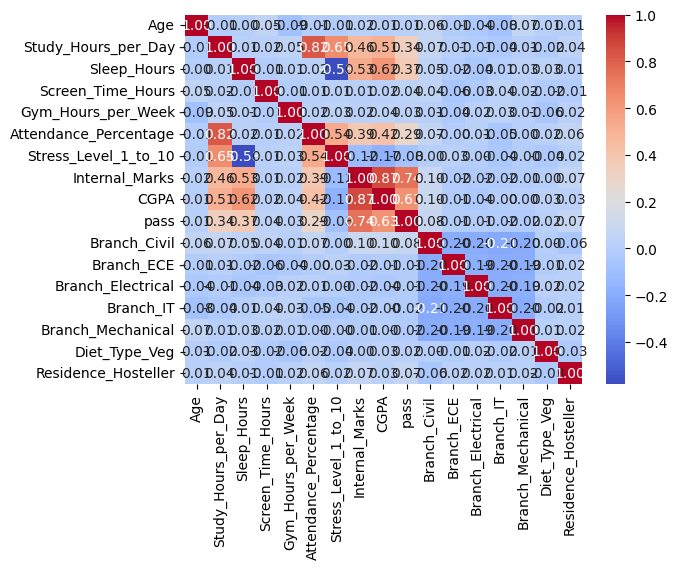

In [40]:
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")

In [39]:
n = 10
lr = LogisticRegression(max_iter=1000)

rfe = RFE(estimator=lr, n_features_to_select=n)

rfe.fit(X, y)

print("Selected features:", X.columns[rfe.support_])
print("Feature ranking:", rfe.ranking_)

Selected features: Index(['Study_Hours_per_Day', 'Screen_Time_Hours', 'CGPA', 'Branch_Civil',
       'Branch_ECE', 'Branch_Electrical', 'Branch_IT', 'Branch_Mechanical',
       'Diet_Type_Veg', 'Residence_Hosteller'],
      dtype='str')
Feature ranking: [3 1 5 1 4 6 2 1 1 1 1 1 1 1 1]


In [ ]:
X_rfe = df_encoded[X.columns[rfe.support_]]
X_rfe

,Study_Hours_per_Day,Screen_Time_Hours,CGPA,Branch_Civil,Branch_ECE,Branch_Electrical,Branch_IT,Branch_Mechanical,Diet_Type_Veg,Residence_Hosteller
0,4.14,9.23,7.52,False,True,False,False,False,False,True
1,5.97,3.09,7.21,True,False,False,False,False,True,False
2,3.19,5.02,4.84,False,False,True,False,False,True,True
3,4.77,9.21,6.74,False,False,False,False,False,False,False
4,5.42,4.76,7.77,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...
995,4.60,4.23,6.65,False,False,False,True,False,False,False
996,4.02,3.88,7.77,False,False,False,True,False,False,True
997,4.28,4.64,8.04,False,False,False,False,False,True,False
998,6.42,4.84,7.24,True,False,False,False,False,False,False


In [43]:
X.shape, X_rfe.shape

((1000, 15), (1000, 10))

In [44]:
X_train, X_test, X_rfe_train, X_rfe_test, y_train, y_test = train_test_split(X, X_rfe, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
lr = LogisticRegression(max_iter=1000)
lr_rfe = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
lr_rfe.fit(X_rfe_train, y_train)

y_pred = lr.predict(X_test)
y_pred_rfe = lr_rfe.predict(X_rfe_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy_rfe = accuracy_score(y_test, y_pred_rfe)

print(f"Accuracy sin RFE: {accuracy:.4f}")
print(f"Accuracy con RFE: {accuracy_rfe:.4f}")

Accuracy sin RFE: 0.8300
Accuracy con RFE: 0.8350


In [50]:
scores = cross_val_score(LogisticRegression(max_iter=20000),X,y, scoring="accuracy", cv = 10)
print('scores: ', scores)
print('score(mean): ', scores.mean())

scores:  [0.83 0.83 0.86 0.86 0.87 0.84 0.86 0.87 0.77 0.77]
score(mean):  0.836


In [68]:
threshold = 0.3

probs = lr.predict_proba(X_test)
probs_rfe = lr_rfe.predict_proba(X_rfe_test)

prob = probs[:,1]
prob_rfe = probs_rfe[:,1]

prob_df = pd.DataFrame(prob)
prob_df['prediction'] = np.where(prob_df[0] >= threshold, 1, 0) 
prob_df['actual'] = list(y_test) 

prob_rfe_df = pd.DataFrame(prob_rfe)
prob_rfe_df['prediction'] = np.where(prob_rfe_df[0] >= threshold, 1, 0)
prob_rfe_df['actual'] = list(y_test)

cm = pd.crosstab(prob_df.prediction, prob_df.actual)
cm_rfe = pd.crosstab(prob_rfe_df.prediction, prob_rfe_df.actual)

print(f'Matriz de confusión (todas las variables), threshold: {threshold}')
accuracy = (cm[0][0] + cm[1][1]) / \
           (cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1])
print(f'Accuracy: {accuracy}')
display(cm)
print(f'Matriz de confusión (10 variables rfe), threshold: {threshold}')
accuracy_rfe = (cm_rfe[0][0] + cm_rfe[1][1]) / \
           (cm_rfe[0][0] + cm_rfe[0][1] + cm_rfe[1][0] + cm_rfe[1][1])
print(f'Accuracy (rfe): {accuracy_rfe}')
display(cm_rfe)

Matriz de confusión (todas las variables), threshold: 0.3
Accuracy: 0.835


actual,0,1
prediction,,
0,29,6
1,27,138


Matriz de confusión (10 variables rfe), threshold: 0.3
Accuracy (rfe): 0.855


actual,0,1
prediction,,
0,31,4
1,25,140


In [93]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9]

sensitivities = [1] # ya incluimos el 1, para completar el gráfico
especifities_c = [1] # 1 - especificidad

for t in thresholds:
    prob_df['prediction'] = np.where(prob_df[0] >= t, 1, 0)
    prob_df['actual'] = list(y_test) ## para que coincidadn los index
    prob_df.head()

    cm = pd.crosstab(prob_df.prediction, prob_df.actual)

    #checamos bien los indices de la matriz
    TN = cm[0][0]
    TP = cm[1][1]
    FN = cm[1][0]
    FP = cm[0][1]

    sens = TP / (TP + FN)
    sensitivities.append(sens)

    espc_c = 1 - TN/(TN + FP)
    especifities_c.append(espc_c)

# rellenamos el otro extremo, donde los valores son cero
sensitivities.append(0)
especifities_c.append(0)

sensitivities

[1,
 np.float64(1.0),
 np.float64(0.9861111111111112),
 np.float64(0.9583333333333334),
 np.float64(0.9375),
 np.float64(0.9027777777777778),
 np.float64(0.8680555555555556),
 np.float64(0.8402777777777778),
 np.float64(0.8263888888888888),
 np.float64(0.7638888888888888),
 np.float64(0.6666666666666666),
 0]

In [94]:
especifities_c

[1,
 np.float64(0.7857142857142857),
 np.float64(0.5714285714285714),
 np.float64(0.4821428571428571),
 np.float64(0.3928571428571429),
 np.float64(0.3571428571428571),
 np.float64(0.3035714285714286),
 np.float64(0.2321428571428571),
 np.float64(0.1428571428571429),
 np.float64(0.0714285714285714),
 np.float64(0.0),
 0]

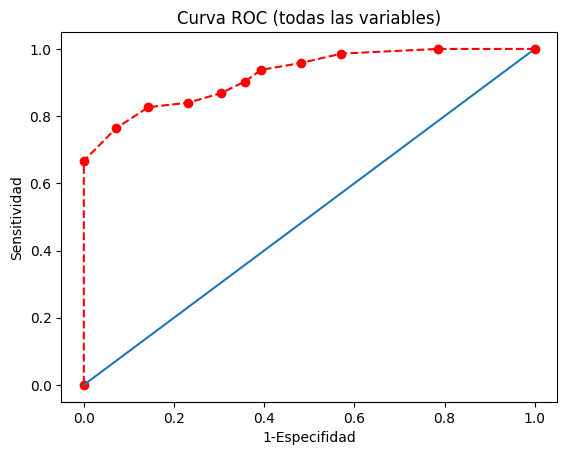

In [95]:
plt.plot(especifities_c,sensitivities, marker = 'o', linestyle = "--", color = 'r')

# pintamos la linea recta
x = [i*0.01 for i in range(100)]
y = [i*0.01 for i in range(100)]

plt.plot(x,y)
plt.xlabel('1-Especifidad')
plt.ylabel('Sensitividad')
plt.title('Curva ROC (todas las variables)')
plt.show()